In [1]:
import dask
import time
import gc

from dask_cuda import LocalCUDACluster
from dask.distributed import Client

In [2]:
import rmm
import cupy as cp

from rmm.allocators.cupy import rmm_cupy_allocator

In [3]:
%%time
cluster = LocalCUDACluster(
    CUDA_VISIBLE_DEVICES="0,1,2,3",
    threads_per_worker=8,
    protocol="ucx",
    rmm_pool_size="10GB",
    rmm_maximum_pool_size="14GB",   # stay under T4's 15GB
    rmm_managed_memory=True,        # spill to RAM instead of OOM
    rmm_allocator_external_lib_list="cupy",
    memory_limit="50GB"             # system RAM per worker (4 workers × 50GB = 200GB)
)
client = Client(cluster)
client

CPU times: user 5.94 s, sys: 1.26 s, total: 7.19 s
Wall time: 7.87 s


Connection method: Cluster object,Cluster type: dask_cuda.LocalCUDACluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 32,Total memory: 186.26 GiB
Status: running,Using processes: True
Comm: ucx://127.0.0.1:36343,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: ucx://127.0.0.1:40137,Total threads: 8
Dashboard: http://127.0.0.1:33085/status,Memory: 46.57 GiB
Nanny: ucx://127.0.0.1:36277,


In [4]:
import rapids_singlecell as rsc
import scanpy as sc
import anndata as ad

In [5]:
from packaging.version import parse as parse_version
import zarr
if parse_version(ad.__version__) < parse_version("0.12.0rc1"):
    from anndata.experimental import read_elem_as_dask as read_dask
else:
    from anndata.experimental import read_elem_lazy as read_dask

SPARSE_CHUNK_SIZE = 5_000
data_pth = "adata.zarr" # 1.1Million Cells

f = zarr.open(data_pth)
X = f["X"]
shape = X.attrs["shape"]
adata = ad.AnnData(
    X = read_dask(X, (SPARSE_CHUNK_SIZE, shape[1])),
    obs = ad.io.read_elem(f["obs"]),
    var = ad.io.read_elem(f["var"])
)

/tmp/ipykernel_6965/525131169.py:3: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if parse_version(ad.__version__) < parse_version("0.12.0rc1"):


In [6]:
adata

AnnData object with n_obs × n_vars = 1171965 × 33538
    obs: 'adt_qc_flag', 'adt_umis', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'ext_l1', 'ext_l2', 'ext_l3', 'healthy_l1', 'healthy_l2', 'healthy_l3', 'aifi_l1', 'aifi_l2', 'aifi_l3', 'predicted_doublet', 'doublet_score', 'sample.sampleKitGuid', 'sample.visitDetails', 'sample.visitName', 'sample.drawDate', 'sample.daysSinceFirstVisit', 'sample.diseaseStatesRecordedAtVisit', 'subject.biologicalSex', 'subject.birthYear', 'subject.ethnicity', 'subject.partnerCode', 'subject.race', 'subject.subjectGuid', 'specimen.specimenGuid', 'cohort.cohortGuid', 'manual.time_stamp', 'tissue', 'manual.response', 'manual.response_type', 'manual.extracted_name', 'manual.batch_id', 'manual.category', 'manual.treatment_dara', 'manual.flu_response',

In [7]:
%%time
rsc.get.anndata_to_GPU(adata)

CPU times: user 124 ms, sys: 41.1 ms, total: 165 ms
Wall time: 107 ms


In [8]:
%%time
rsc.pp.calculate_qc_metrics(adata)

CPU times: user 9.46 s, sys: 514 ms, total: 9.97 s
Wall time: 9.9 s


In [9]:
%%time
rsc.pp.normalize_total(adata)
rsc.pp.log1p(adata)

CPU times: user 7.9 s, sys: 443 ms, total: 8.34 s
Wall time: 8.25 s


In [10]:
%%time
rsc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.25)

CPU times: user 7.53 s, sys: 369 ms, total: 7.9 s
Wall time: 7.86 s


In [11]:
%%time
rsc.pp.scale(adata, max_value=10, zero_center=False)

CPU times: user 7.38 s, sys: 360 ms, total: 7.74 s
Wall time: 7.69 s


In [12]:
%%time
rsc.pp.pca(adata, svd_solver="arpack")

CPU times: user 47.5 s, sys: 2.11 s, total: 49.6 s
Wall time: 48.9 s


In [13]:
%%time
adata.obsm["X_pca"] = adata.obsm["X_pca"].compute()

CPU times: user 43.1 s, sys: 1.97 s, total: 45.1 s
Wall time: 45 s


In [14]:
%%time
adata.obsm["X_pca"] = adata.obsm["X_pca"].get()

CPU times: user 125 ms, sys: 48 ms, total: 173 ms
Wall time: 86.1 ms


In [15]:
%%time
rsc.pp.neighbors(adata, n_neighbors=50, use_rep="X_pca", n_pcs=20)

CPU times: user 1min 37s, sys: 926 ms, total: 1min 38s
Wall time: 1min 36s


In [16]:
%%time
rsc.tl.umap(adata, min_dist=0.45, init_pos='spectral', random_state=0, n_components=2)

CPU times: user 42.5 s, sys: 1.26 s, total: 43.8 s
Wall time: 43.5 s


In [18]:
%%time
rsc.tl.leiden(adata, resolution=1, n_iterations=2)

CPU times: user 34 s, sys: 7.3 s, total: 41.3 s
Wall time: 39 s


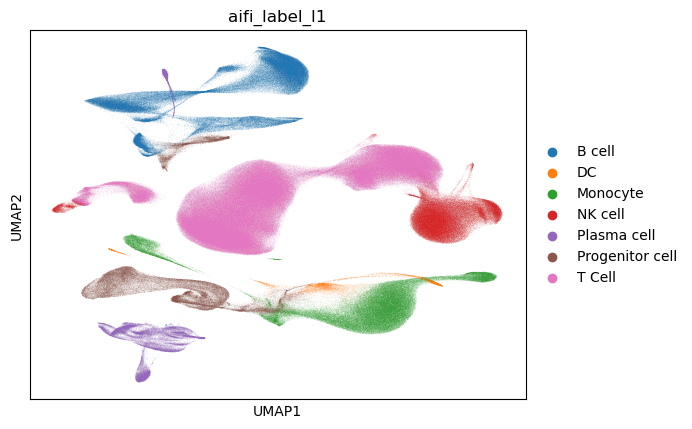

In [17]:
sc.pl.umap(adata, color = 'aifi_label_l1')

In [20]:
adata

AnnData object with n_obs × n_vars = 1171965 × 33538
    obs: 'adt_qc_flag', 'adt_umis', 'batch_id', 'cell_name', 'cell_uuid', 'chip_id', 'hto_barcode', 'hto_category', 'n_genes', 'n_mito_umis', 'n_reads', 'n_umis', 'original_barcodes', 'pbmc_sample_id', 'pool_id', 'seurat_pbmc_type', 'seurat_pbmc_type_score', 'umap_1', 'umap_2', 'well_id', 'ext_l1', 'ext_l2', 'ext_l3', 'healthy_l1', 'healthy_l2', 'healthy_l3', 'aifi_l1', 'aifi_l2', 'aifi_l3', 'predicted_doublet', 'doublet_score', 'sample.sampleKitGuid', 'sample.visitDetails', 'sample.visitName', 'sample.drawDate', 'sample.daysSinceFirstVisit', 'sample.diseaseStatesRecordedAtVisit', 'subject.biologicalSex', 'subject.birthYear', 'subject.ethnicity', 'subject.partnerCode', 'subject.race', 'subject.subjectGuid', 'specimen.specimenGuid', 'cohort.cohortGuid', 'manual.time_stamp', 'tissue', 'manual.response', 'manual.response_type', 'manual.extracted_name', 'manual.batch_id', 'manual.category', 'manual.treatment_dara', 'manual.flu_response',

In [21]:
adata.write('../../save_rapids_results.h5ad')